In [1]:
import sounddevice as sd
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Echo Cancelling Speakerphone (r, MME (6 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Sceptre K27 (NVIDIA High Defini, MME (0 in, 2 out)
   4 Echo Cancelling Speakerphone (r, MME (0 in, 2 out)
   5 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   6 Echo Cancelling Speakerphone (reSpeaker XVF3800 4-Mic Array), Windows DirectSound (6 in, 0 out)
   7 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   8 Sceptre K27 (NVIDIA High Definition Audio), Windows DirectSound (0 in, 2 out)
   9 Echo Cancelling Speakerphone (reSpeaker XVF3800 4-Mic Array), Windows DirectSound (0 in, 2 out)
  10 Echo Cancelling Speakerphone (reSpeaker XVF3800 4-Mic Array), Windows WASAPI (0 in, 2 out)
  11 Sceptre K27 (NVIDIA High Definition Audio), Windows WASAPI (0 in, 2 out)
  12 Echo Cancelling Speakerphone (reSpeaker XVF3800 4-Mic Array), Windows WASAPI (2 in, 0 out)
  13 Output (reSpeaker XVF3800 4-Mic

In [15]:
import numpy as np
fs = 16000
data = sd.rec(int(5 * fs), samplerate=fs, channels=6, device=14)
sd.wait()
print(data.shape)

(80000, 6)


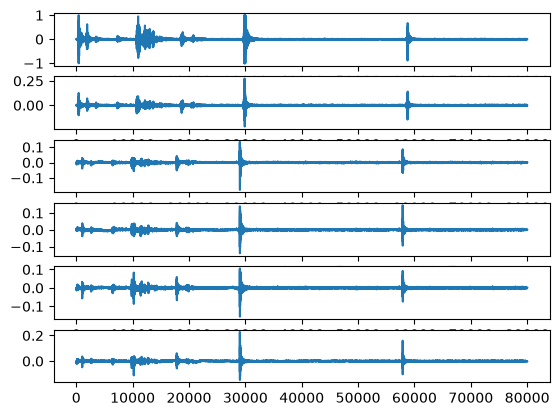

In [16]:
import matplotlib.pyplot as plt
for ch in range(6):
    plt.subplot(6, 1, ch + 1)
    plt.plot(data[:, ch])
plt.show()

In [17]:
peak = np.argmax(np.abs(data[:, 2]))
seg = data[peak - 80 : peak + 80, :]
for ch in [3, 4, 5]:
    c = np.correlate(seg[:, ch], seg[:, 2], mode="full")
    lag = np.argmax(c) - (len(seg) - 1)
    print("channel", ch, "vs 2, lag =", lag, "samples")

channel 3 vs 2, lag = 2 samples
channel 4 vs 2, lag = 1 samples
channel 5 vs 2, lag = -2 samples


In [18]:
from scipy.io import wavfile
wavfile.write("clap_test3.wav", fs, data)

In [19]:
half = 40000
peaks = [np.argmax(np.abs(data[:half, 2])), half + np.argmax(np.abs(data[half:, 2]))]
for p in peaks:
    seg = data[p - 80 : p + 80, :]
    print("clap at sample", p)
    for ch in [3, 4, 5]:
        c = np.correlate(seg[:, ch], seg[:, 2], mode="full")
        lag = np.argmax(c) - (len(seg) - 1)
        print("  channel", ch, "vs 2, lag =", lag)

clap at sample 29035
  channel 3 vs 2, lag = 2
  channel 4 vs 2, lag = 1
  channel 5 vs 2, lag = -2
clap at sample 57910
  channel 3 vs 2, lag = 3
  channel 4 vs 2, lag = 2
  channel 5 vs 2, lag = 0


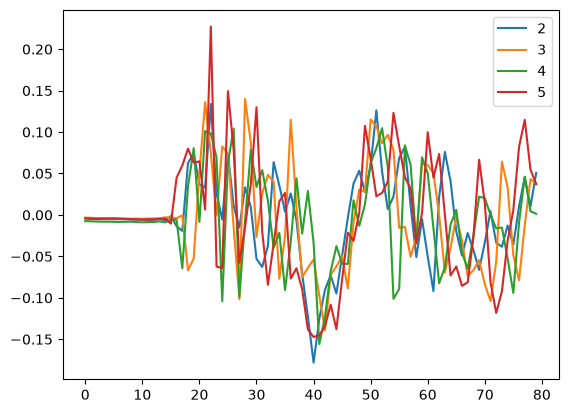

In [20]:
p = peaks[0]
for ch in [2, 3, 4, 5]:
    plt.plot(data[p - 40 : p + 40, ch], label=str(ch))
plt.legend()
plt.show()

In [21]:
for ch in [2, 3, 4, 5]:
    print("channel", ch, "max =", np.max(np.abs(data[:, ch])))

channel 2 max = 0.1781311
channel 3 max = 0.14593506
channel 4 max = 0.1559143
channel 5 max = 0.22723389
